# 🏦 Bank Customer Churn Analysis — Bitirme Projesi

**Proje Amacı:** Bir bankanın müşteri kaybını (churn) analiz ederek hangi müşterilerin bankayı terk etme eğiliminde olduğunu tespit etmek ve aksiyonlar önermek.

**Veri Seti:** [Kaggle — Bank Customer Churn Prediction](https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset)

**Pipeline:** Kaggle → Fivetran → BigQuery → dbt → Looker Studio & Power BI

---
## 1. Kütüphaneler ve Veri Yükleme

In [53]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('darkgrid')
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [54]:
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
## 2. Veri Kalite Kontrolü

In [55]:
print("Veri Seti Boyutu:", df.shape)
print("\nSütun Bilgileri:")
df.info()

Veri Seti Boyutu: (10000, 12)

Sütun Bilgileri:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [56]:
print("Eksik Veri Kontrolü:")
print(df.isnull().sum())
print(f"\nToplam eksik veri: {df.isnull().sum().sum()}")

Eksik Veri Kontrolü:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Toplam eksik veri: 0


In [57]:
print(f"Duplike satır sayısı: {df.duplicated().sum()}")
print(f"Duplike customer_id sayısı: {df['customer_id'].duplicated().sum()}")

Duplike satır sayısı: 0
Duplike customer_id sayısı: 0


In [58]:
print("Temel İstatistikler:")
df.describe().round(2)

Temel İstatistikler:


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


---
## 3. Hedef Değişken Analizi (Churn Dağılımı)

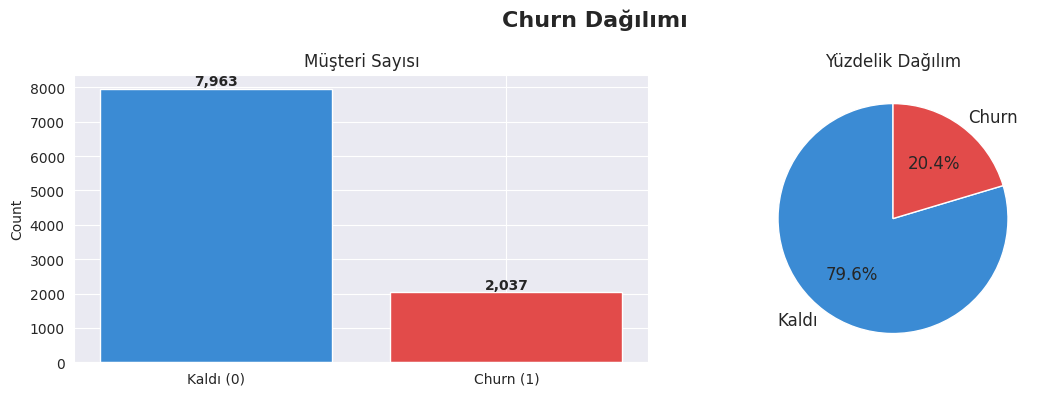

Churn oranı: %20.4


In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Churn Dağılımı', fontsize=16, fontweight='bold')

# Count
churn_counts = df['churn'].value_counts()
labels_count = ['Kaldı (0)', 'Churn (1)']
colors = ['#3B8BD4', '#E24B4A']
ax1.bar(labels_count, churn_counts.values, color=colors, edgecolor='white')
for i, v in enumerate(churn_counts.values):
    ax1.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
ax1.set_title('Müşteri Sayısı')
ax1.set_ylabel('Count')

# Percentage
ax2.pie(churn_counts.values, labels=['Kaldı', 'Churn'], colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax2.set_title('Yüzdelik Dağılım')

plt.tight_layout()
plt.show()

print(f"Churn oranı: %{df['churn'].mean()*100:.1f}")

---
## 4. Kategorik Değişken Analizi

### 4.1 Cinsiyet Dağılımı ve Churn

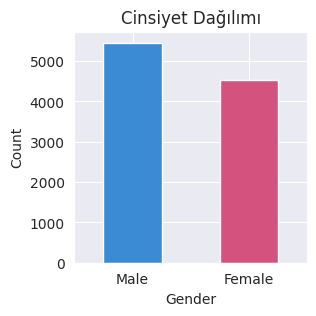

Counter({'Female': 4543, 'Male': 5457})

In [60]:
plt.figure(figsize=(3, 3))
df['gender'].value_counts().plot.bar(color=['#3B8BD4', '#D4537E'])
plt.ylabel('Count')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.title('Cinsiyet Dağılımı')
plt.show()
Counter(df.gender)

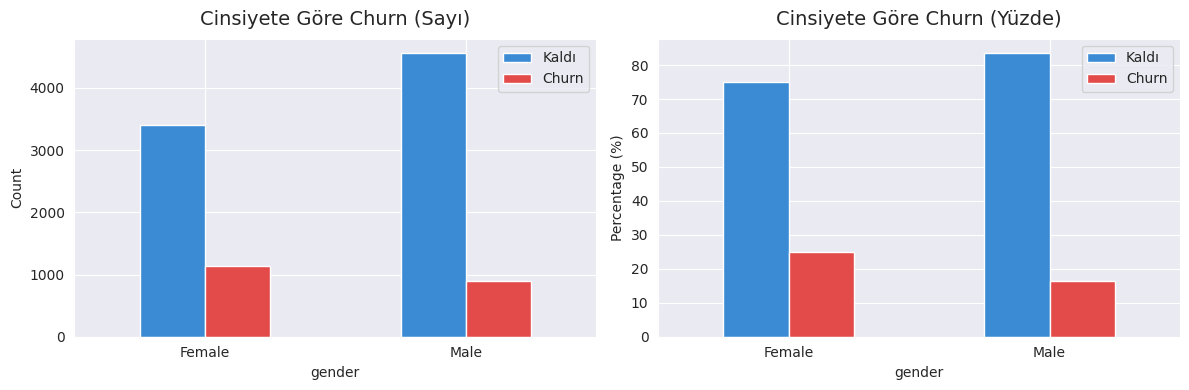

In [61]:
grouped = df.groupby('gender')['churn'].agg(Count='value_counts')
dfgc = grouped.pivot_table(values='Count', index='gender', columns=['churn'])

dfgp = grouped.groupby(level=[0]).apply(lambda g: round(g * 100 / g.sum(), 2))
dfgp.rename(columns={'Count': 'Percentage'}, inplace=True)
dfgp = dfgp.pivot_table(values='Percentage', index='gender', columns=['churn'])

labels = ['Kaldı', 'Churn']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

dfgc.plot(kind='bar', color=['#3B8BD4', '#E24B4A'], rot=0, ax=ax1)
ax1.legend(labels)
ax1.set_title('Cinsiyete Göre Churn (Sayı)', fontsize=14, pad=10)
ax1.set_ylabel('Count')

dfgp.plot(kind='bar', color=['#3B8BD4', '#E24B4A'], rot=0, ax=ax2)
ax2.legend(labels)
ax2.set_title('Cinsiyete Göre Churn (Yüzde)', fontsize=14, pad=10)
ax2.set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

### 4.2 Ülke Dağılımı ve Churn

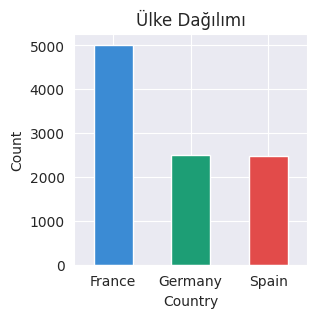

Counter({'France': 5014, 'Spain': 2477, 'Germany': 2509})

In [62]:
plt.figure(figsize=(3, 3))
df['country'].value_counts().plot.bar(color=['#3B8BD4', '#1D9E75', '#E24B4A'])
plt.ylabel('Count')
plt.xlabel('Country')
plt.xticks(rotation=0)
plt.title('Ülke Dağılımı')
plt.show()
Counter(df.country)

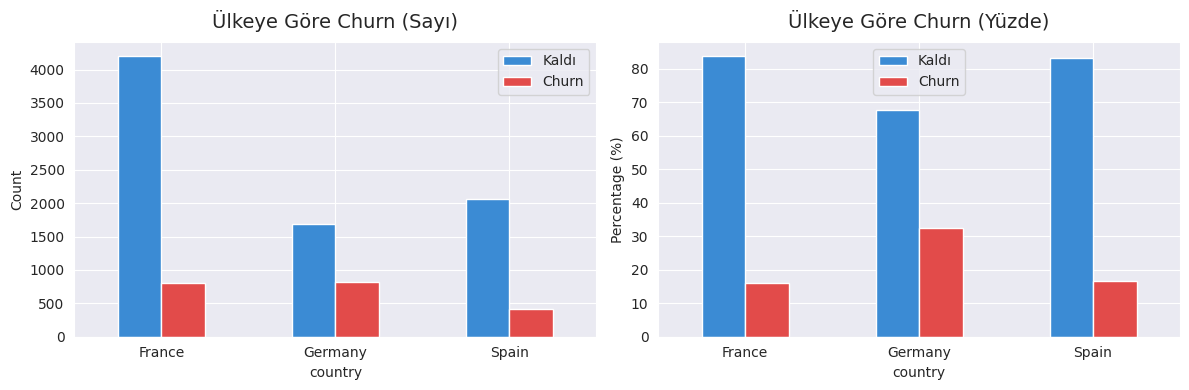

In [63]:
grouped = df.groupby('country')['churn'].agg(Count='value_counts')
dfgeoc = grouped.pivot_table(values='Count', index='country', columns=['churn'])

dfgeop = grouped.groupby(level=[0]).apply(lambda g: round(g * 100 / g.sum(), 2))
dfgeop.rename(columns={'Count': 'Percentage'}, inplace=True)
dfgeop = dfgeop.pivot_table(values='Percentage', index='country', columns=['churn'])

labels = ['Kaldı', 'Churn']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

dfgeoc.plot(kind='bar', color=['#3B8BD4', '#E24B4A'], rot=0, ax=ax1)
ax1.legend(labels)
ax1.set_title('Ülkeye Göre Churn (Sayı)', fontsize=14, pad=10)
ax1.set_ylabel('Count')

dfgeop.plot(kind='bar', color=['#3B8BD4', '#E24B4A'], rot=0, ax=ax2)
ax2.legend(labels)
ax2.set_title('Ülkeye Göre Churn (Yüzde)', fontsize=14, pad=10)
ax2.set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

---
## 5. Sayısal Değişken Dağılımları

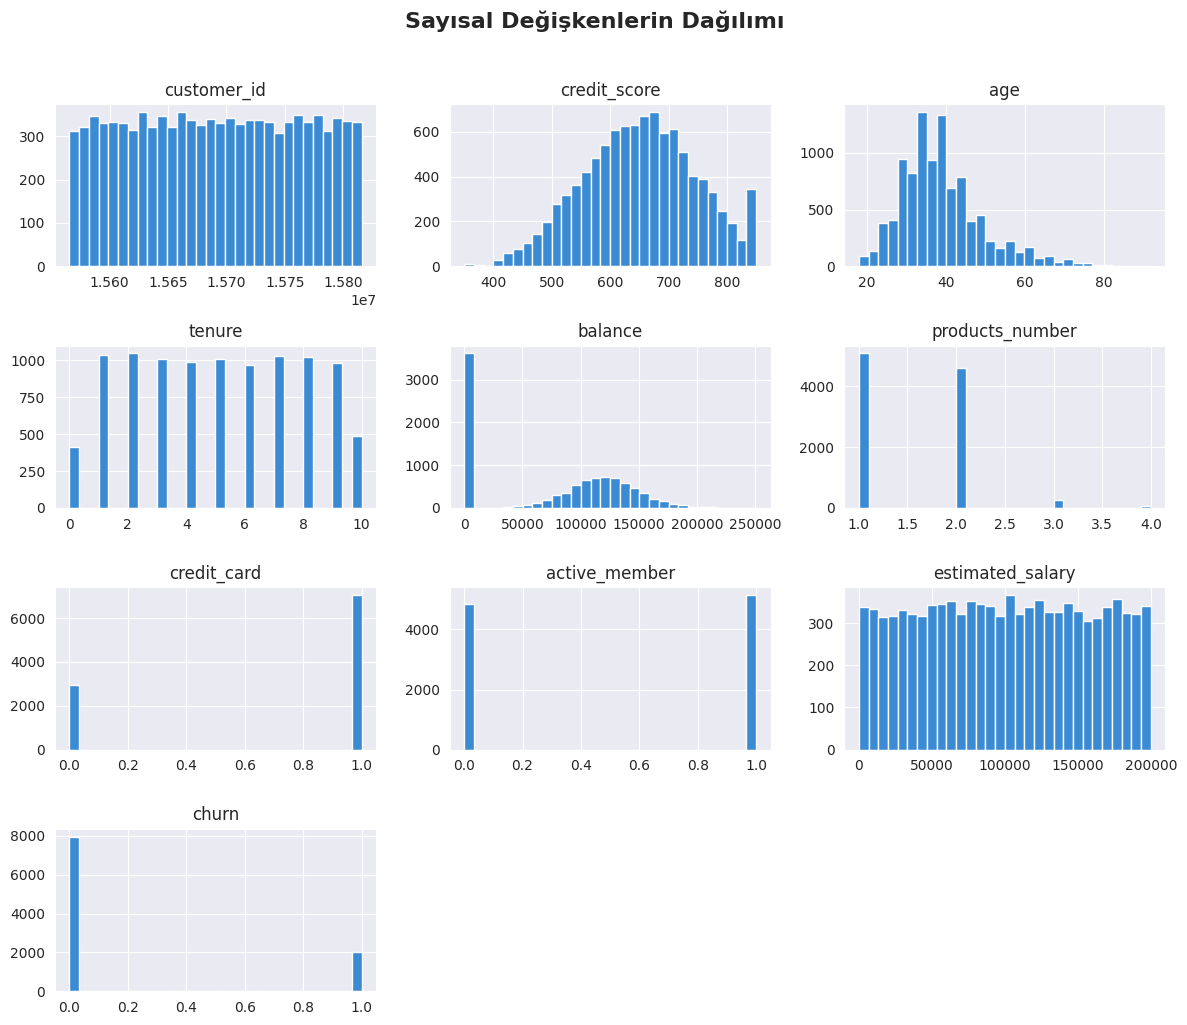

In [64]:
df.hist(figsize=(12, 10), bins=30, edgecolor='white', color='#3B8BD4')
plt.suptitle('Sayısal Değişkenlerin Dağılımı', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Korelasyon Analizi

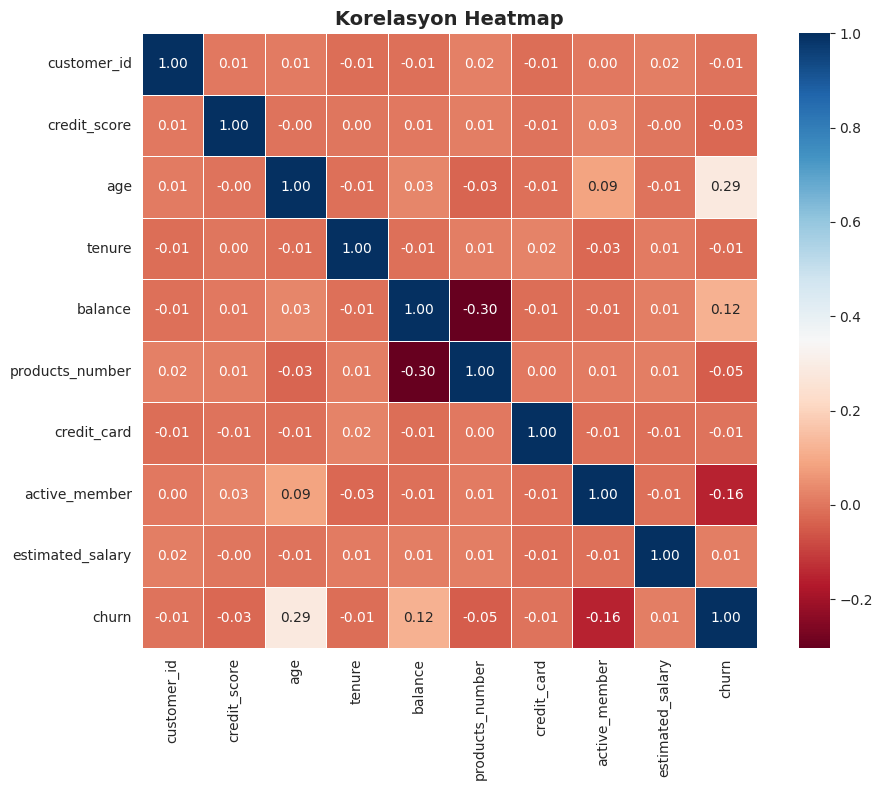


Churn ile korelasyon sıralaması:
age                 0.285323
balance             0.118533
estimated_salary    0.012097
customer_id        -0.006248
credit_card        -0.007138
tenure             -0.014001
credit_score       -0.027094
products_number    -0.047820
active_member      -0.156128


In [65]:
df_numeric = df.select_dtypes(include=[np.number])
correlation = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation,
            cmap='RdBu',
            annot=True,
            fmt='.2f',
            cbar=True,
            square=True,
            linewidths=0.5)
plt.title('Korelasyon Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nChurn ile korelasyon sıralaması:")
print(correlation['churn'].drop('churn').sort_values(ascending=False).to_string())

---
## 7. Churn vs Değişken Karşılaştırmaları (Violin Plot)

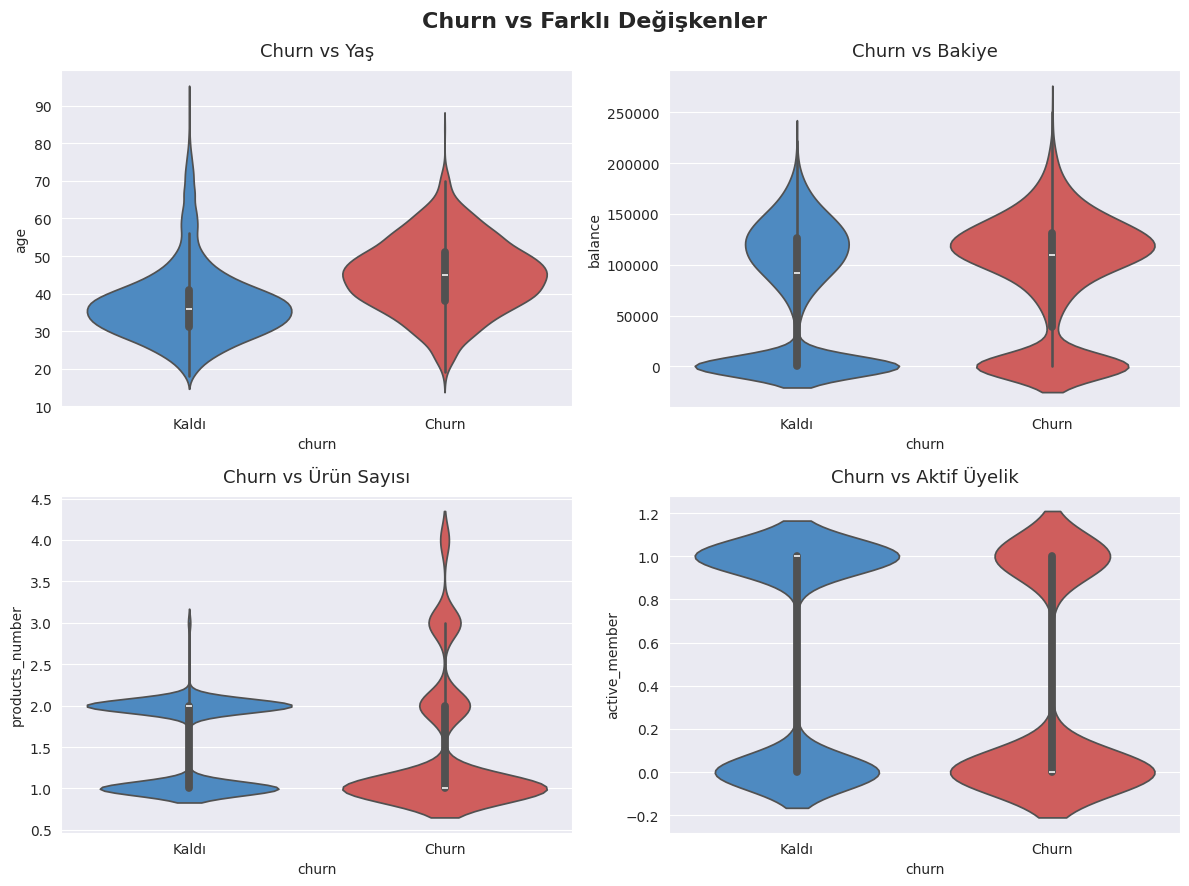

In [66]:
my_pal = {'Kaldı': '#3B8BD4', 'Churn': '#E24B4A'}
hr = {0: 'Kaldı', 1: 'Churn'}
churn_label = df['churn'].map(hr)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Churn vs Farklı Değişkenler', fontsize=16, fontweight='bold')
fig.subplots_adjust(top=0.92, wspace=0.3, hspace=0.3)

sns.violinplot(x=churn_label, y=df['age'], order=['Kaldı', 'Churn'], palette=my_pal, ax=ax1)
ax1.set_title('Churn vs Yaş', fontsize=13, pad=10)

sns.violinplot(x=churn_label, y=df['balance'], order=['Kaldı', 'Churn'], palette=my_pal, ax=ax2)
ax2.set_title('Churn vs Bakiye', fontsize=13, pad=10)

sns.violinplot(x=churn_label, y=df['products_number'], order=['Kaldı', 'Churn'], palette=my_pal, ax=ax3)
ax3.set_title('Churn vs Ürün Sayısı', fontsize=13, pad=10)

sns.violinplot(x=churn_label, y=df['active_member'], order=['Kaldı', 'Churn'], palette=my_pal, ax=ax4)
ax4.set_title('Churn vs Aktif Üyelik', fontsize=13, pad=10)

plt.tight_layout()
plt.show()

---
## 8. Pairplot Analizi

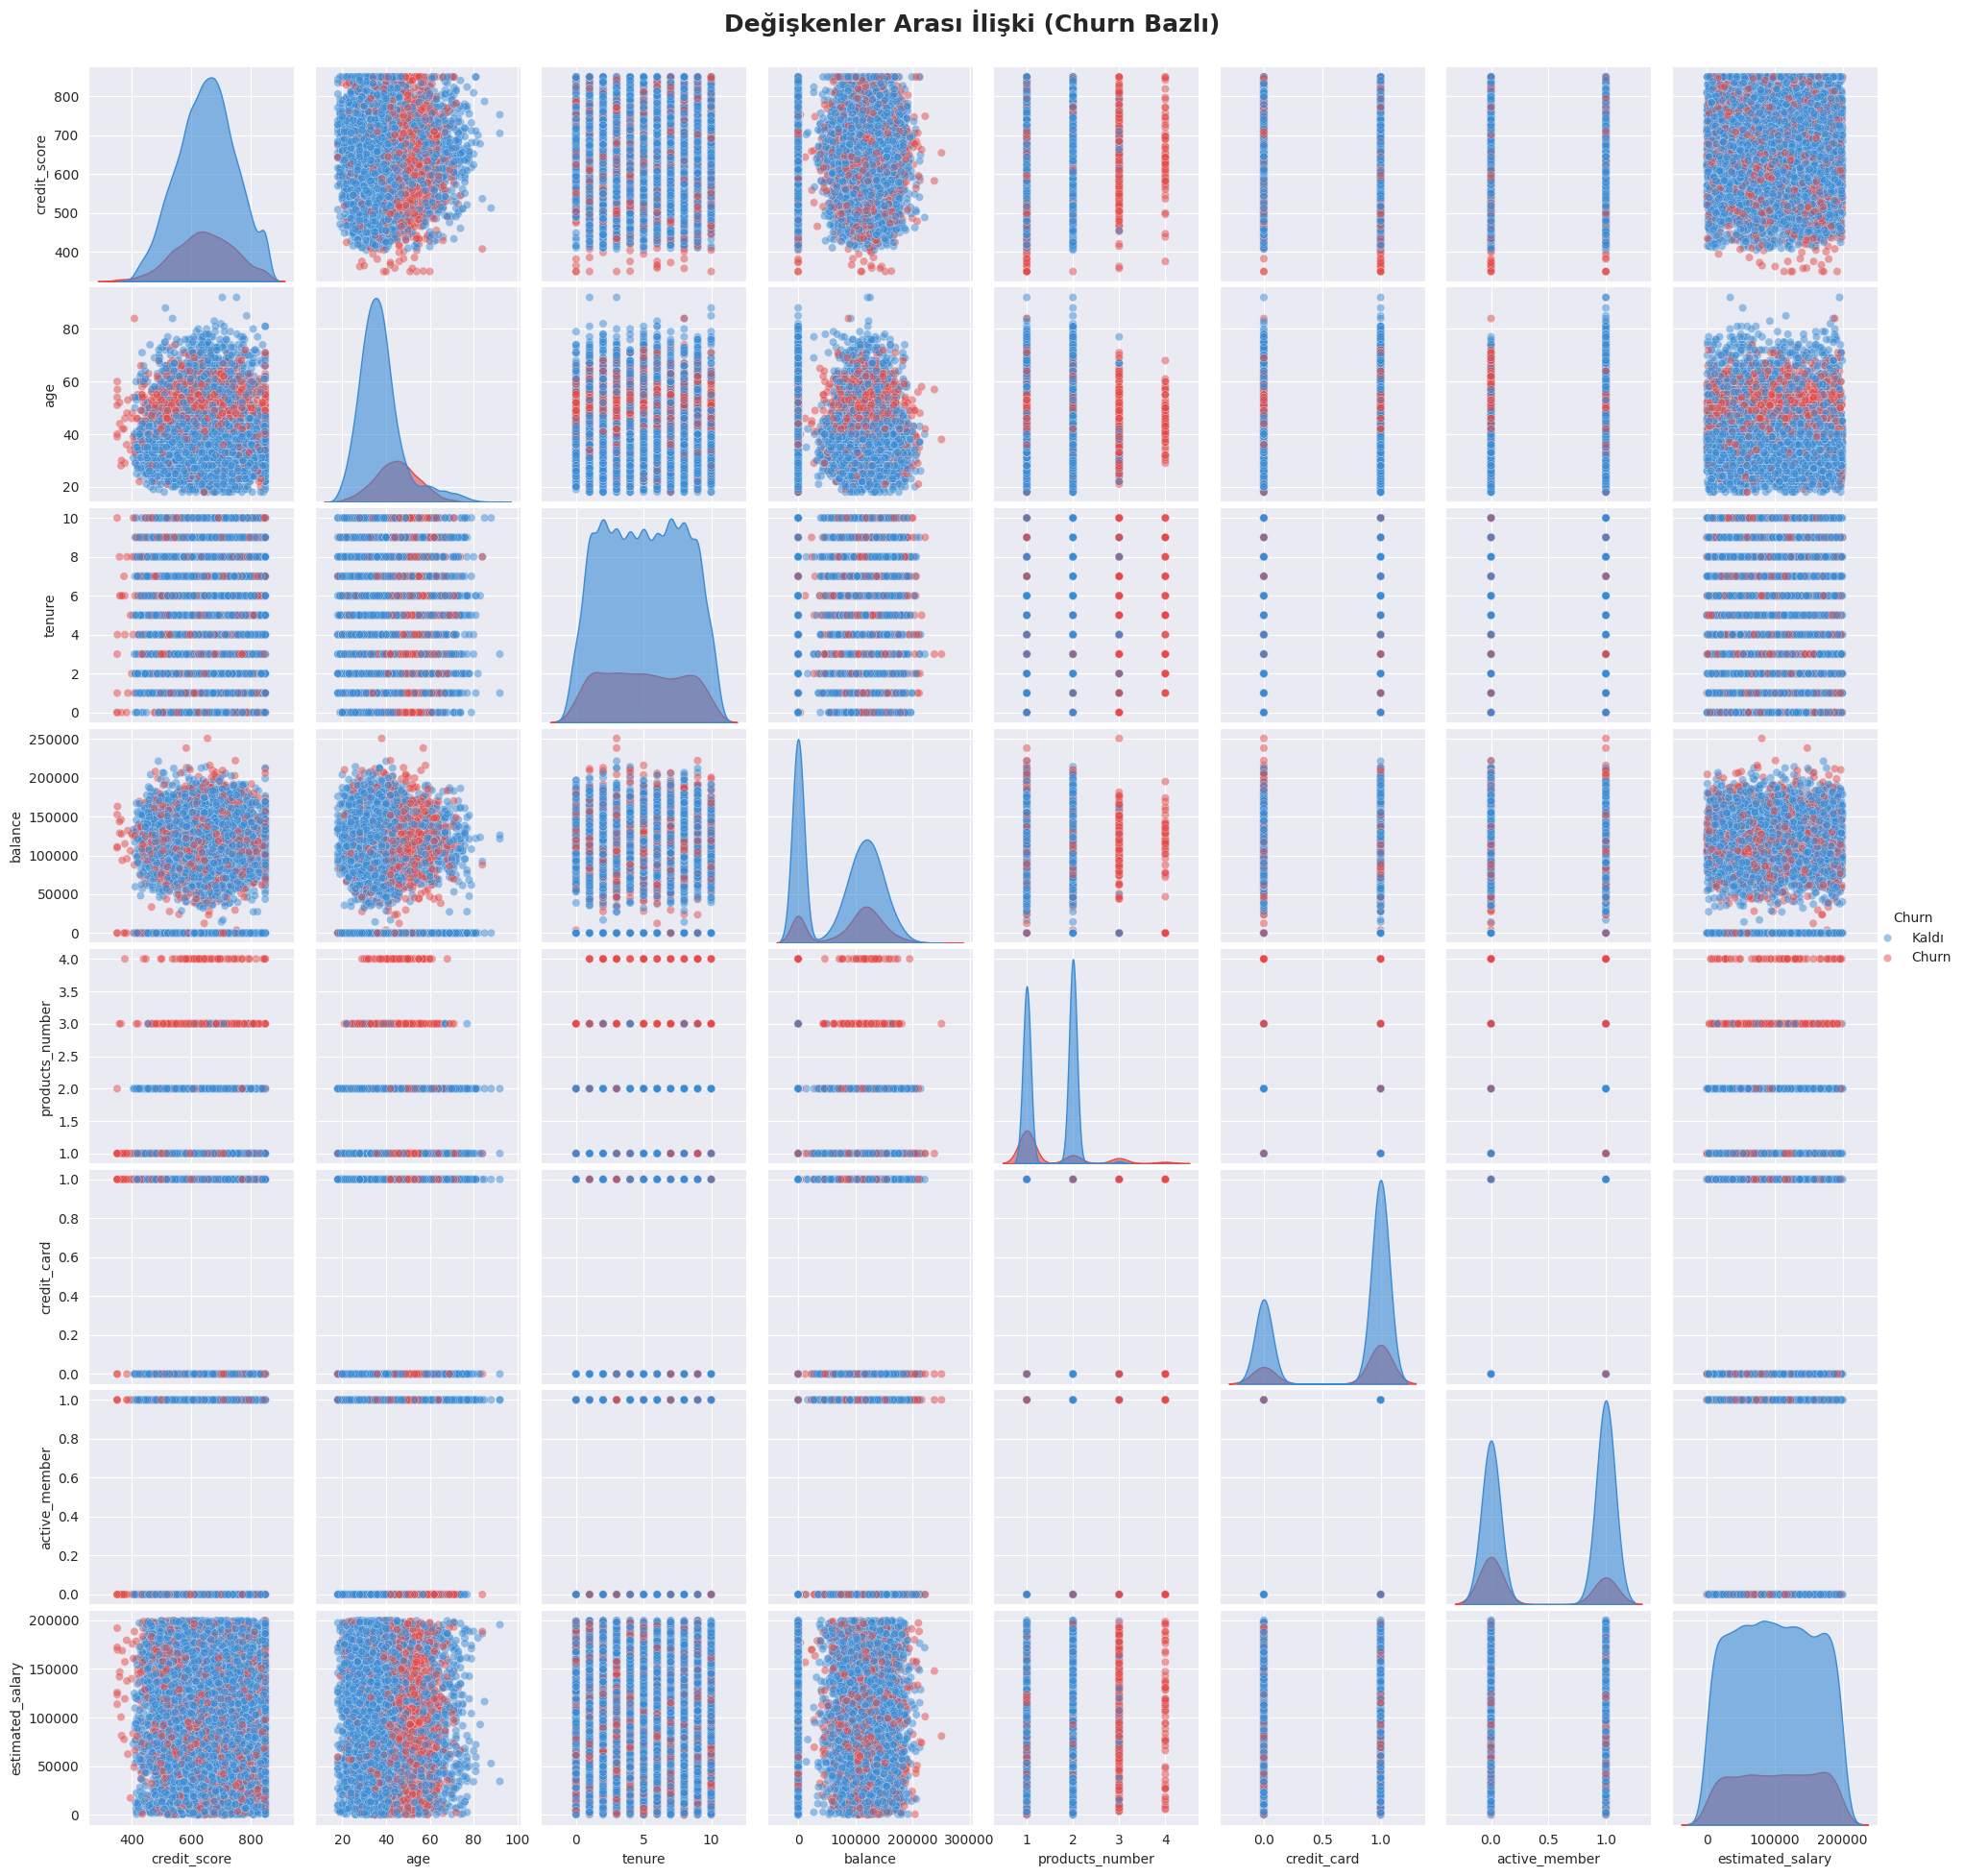

In [67]:
g = sns.pairplot(df.drop(columns=['customer_id']), hue='churn',
                 palette={1: '#E24B4A', 0: '#3B8BD4'},
                 plot_kws={'alpha': 0.5, 'edgecolor': 'white', 'linewidth': 0.3},
                 diag_kws={'alpha': 0.6})
fig = g.fig
fig.subplots_adjust(top=0.95, wspace=0.1)
fig.suptitle('Değişkenler Arası İlişki (Churn Bazlı)', fontsize=18, fontweight='bold')

g._legend.set_title('Churn')
for t, l in zip(g._legend.texts, ['Kaldı', 'Churn']):
    t.set_text(l)
plt.show()

---
## 9. Detaylı Segment Analizi

### 9.1 Yaş Gruplarına Göre Churn

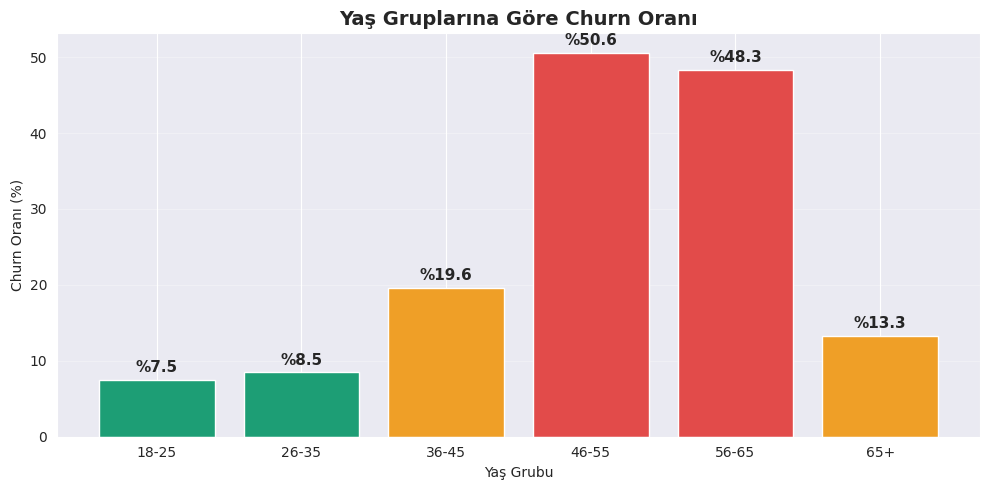

In [68]:
df['age_group'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,100],
                         labels=['18-25','26-35','36-45','46-55','56-65','65+'])

churn_by_age = df.groupby('age_group')['churn'].agg(['mean','count','sum'])
churn_by_age.columns = ['churn_rate', 'total', 'churned']
churn_by_age['churn_rate'] = (churn_by_age['churn_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(churn_by_age.index.astype(str), churn_by_age['churn_rate'],
              color=['#1D9E75','#1D9E75','#EF9F27','#E24B4A','#E24B4A','#EF9F27'],
              edgecolor='white')
for bar, rate in zip(bars, churn_by_age['churn_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'%{rate}', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Yaş Gruplarına Göre Churn Oranı', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Oranı (%)')
ax.set_xlabel('Yaş Grubu')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Ürün Sayısına Göre Churn

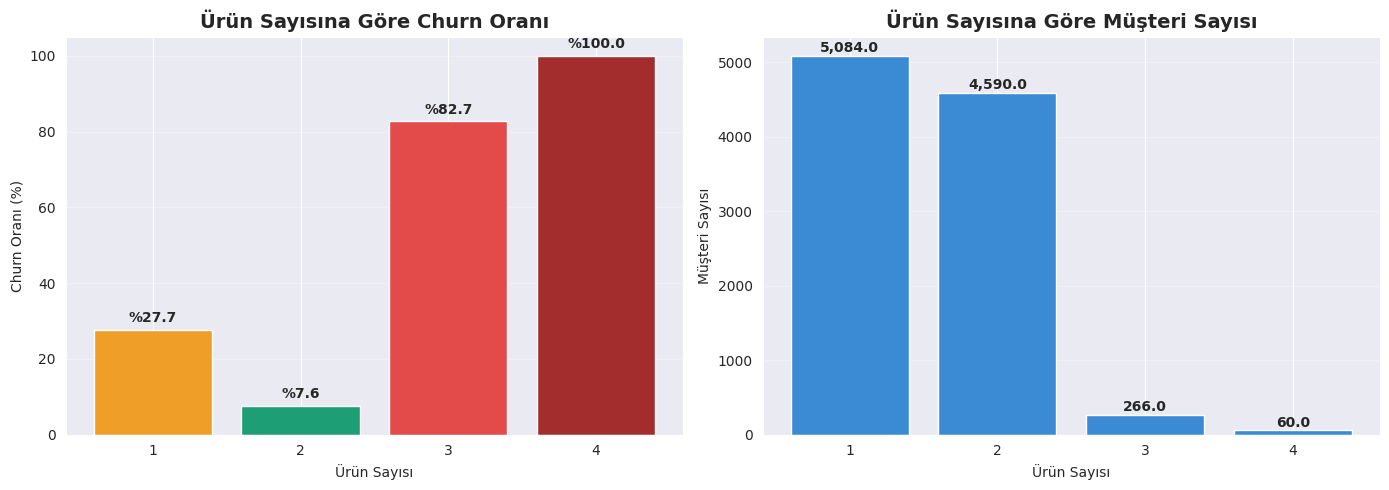

In [69]:
churn_by_prod = df.groupby('products_number')['churn'].agg(['mean','count','sum'])
churn_by_prod.columns = ['churn_rate', 'total', 'churned']
churn_by_prod['churn_rate'] = (churn_by_prod['churn_rate'] * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate
colors_prod = ['#EF9F27', '#1D9E75', '#E24B4A', '#A32D2D']
ax1.bar(churn_by_prod.index.astype(str), churn_by_prod['churn_rate'],
        color=colors_prod, edgecolor='white')
for i, (idx, row) in enumerate(churn_by_prod.iterrows()):
    ax1.text(i, row['churn_rate'] + 2, f"%{row['churn_rate']}", ha='center', fontweight='bold')
ax1.set_title('Ürün Sayısına Göre Churn Oranı', fontsize=14, fontweight='bold')
ax1.set_ylabel('Churn Oranı (%)')
ax1.set_xlabel('Ürün Sayısı')
ax1.grid(axis='y', alpha=0.3)

# Count
ax2.bar(churn_by_prod.index.astype(str), churn_by_prod['total'], color='#3B8BD4', edgecolor='white')
for i, (idx, row) in enumerate(churn_by_prod.iterrows()):
    ax2.text(i, row['total'] + 50, f"{row['total']:,}", ha='center', fontweight='bold')
ax2.set_title('Ürün Sayısına Göre Müşteri Sayısı', fontsize=14, fontweight='bold')
ax2.set_ylabel('Müşteri Sayısı')
ax2.set_xlabel('Ürün Sayısı')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 9.3 Çapraz Segment Analizi

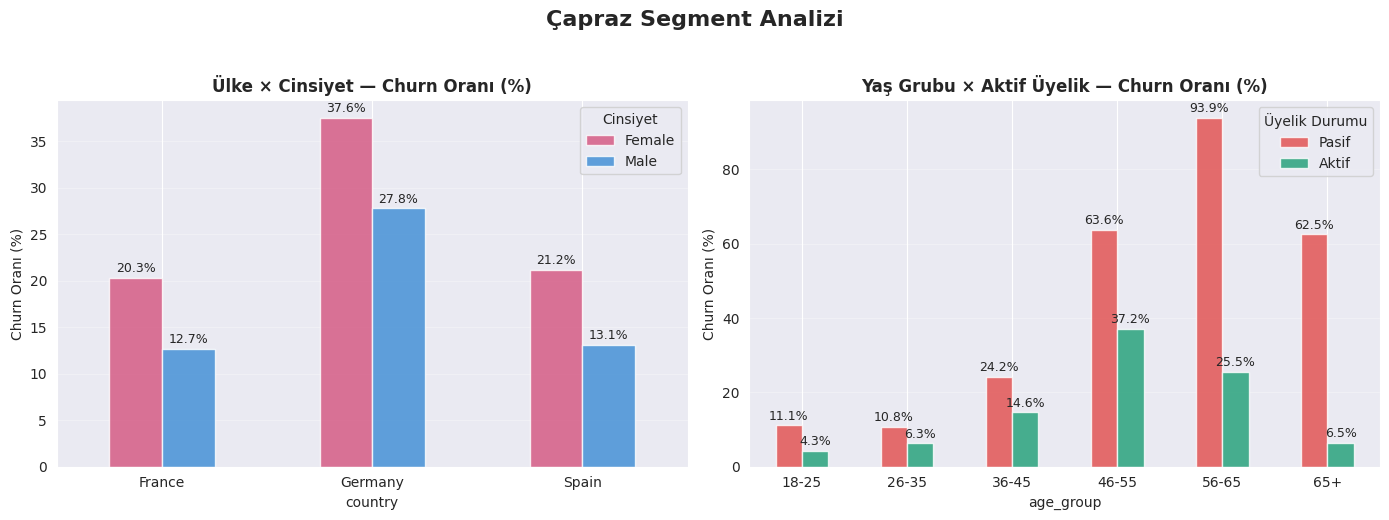

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Çapraz Segment Analizi', fontsize=16, fontweight='bold', y=1.03)

# Country × Gender
cross = df.groupby(['country','gender'])['churn'].mean().unstack() * 100
cross.plot(kind='bar', ax=ax1, color=['#D4537E','#3B8BD4'], alpha=0.8, rot=0)
ax1.set_title('Ülke × Cinsiyet — Churn Oranı (%)', fontweight='bold')
ax1.set_ylabel('Churn Oranı (%)')
ax1.legend(title='Cinsiyet')
ax1.grid(axis='y', alpha=0.3)
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

# Active Member × Age Group
cross2 = df.groupby(['age_group','active_member'])['churn'].mean().unstack() * 100
cross2.columns = ['Pasif', 'Aktif']
cross2.plot(kind='bar', ax=ax2, color=['#E24B4A','#1D9E75'], alpha=0.8, rot=0)
ax2.set_title('Yaş Grubu × Aktif Üyelik — Churn Oranı (%)', fontweight='bold')
ax2.set_ylabel('Churn Oranı (%)')
ax2.legend(title='Üyelik Durumu')
ax2.grid(axis='y', alpha=0.3)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', fontsize=9, padding=2)

plt.tight_layout()
plt.show()

---
## 10. Feature Engineering

In [71]:
# Yaş grubu (zaten oluşturuldu)
# Bakiye değişkenleri
df['is_zero_balance'] = (df['balance'] == 0).astype(int)
df['balance_salary_ratio'] = (df['balance'] / df['estimated_salary'].replace(0, np.nan)).round(4).fillna(0)

balance_median = df.loc[df['balance'] > 0, 'balance'].median()
df['is_high_balance'] = (df['balance'] > balance_median).astype(int)

df['balance_segment'] = pd.cut(df['balance'],
    bins=[-1, 0, 50000, 100000, 150000, 300000],
    labels=['Sıfır', 'Düşük', 'Orta', 'Yüksek', 'Çok Yüksek'])

# Kredi skoru kategorisi
df['credit_score_cat'] = pd.cut(df['credit_score'],
    bins=[0, 500, 600, 700, 800, 900],
    labels=['Çok Düşük', 'Düşük', 'Orta', 'İyi', 'Mükemmel'])

# Ürün değişkenleri
df['tenure_age_ratio'] = (df['tenure'] / df['age']).round(4)
df['products_per_tenure'] = (df['products_number'] / (df['tenure'] + 1)).round(4)
df['is_multi_product'] = (df['products_number'] >= 2).astype(int)
df['is_high_risk_products'] = (df['products_number'] >= 3).astype(int)

# Engagement skoru (0-3)
df['engagement_score'] = (df['active_member'] + df['credit_card'] + (df['balance'] > 0).astype(int))

# Bileşik Churn Risk Skoru (0-5)
df['churn_risk_score'] = (
    (df['age'] >= 45).astype(int) +
    (df['active_member'] == 0).astype(int) +
    (df['products_number'] >= 3).astype(int) +
    (df['country'] == 'Germany').astype(int) +
    (df['balance'] == 0).astype(int)
)

print(f"Feature engineering tamamlandı!")
print(f"Yeni sütun sayısı: {df.shape[1]} (orijinal: 12)")
print(f"\nEklenen değişkenler:")
new_cols = ['age_group', 'is_zero_balance', 'balance_salary_ratio', 'is_high_balance',
            'balance_segment', 'credit_score_cat', 'tenure_age_ratio', 'products_per_tenure',
            'is_multi_product', 'is_high_risk_products', 'engagement_score', 'churn_risk_score']
for col in new_cols:
    print(f"  + {col}")

Feature engineering tamamlandı!
Yeni sütun sayısı: 24 (orijinal: 12)

Eklenen değişkenler:
  + age_group
  + is_zero_balance
  + balance_salary_ratio
  + is_high_balance
  + balance_segment
  + credit_score_cat
  + tenure_age_ratio
  + products_per_tenure
  + is_multi_product
  + is_high_risk_products
  + engagement_score
  + churn_risk_score


---
## 11. Risk Skoru Doğrulaması

In [72]:
risk_map = {0: 'Çok Düşük', 1: 'Düşük', 2: 'Orta', 3: 'Yüksek', 4: 'Çok Yüksek', 5: 'Kritik'}
df['churn_risk_segment'] = df['churn_risk_score'].map(risk_map)

print("Churn Risk Skoru vs Gerçek Churn Oranı")
print("=" * 55)
for score in sorted(df['churn_risk_score'].unique()):
    subset = df[df['churn_risk_score'] == score]
    rate = subset['churn'].mean() * 100
    count = len(subset)
    label = risk_map.get(score, '?')
    bar = '█' * int(rate / 2)
    print(f"  Skor {score} ({label:12s}): {bar:50s} %{rate:.1f} (n={count:,})")

print(f"\n📊 Risk skoru, gerçek churn davranışını güçlü şekilde yakalıyor!")

Churn Risk Skoru vs Gerçek Churn Oranı
  Skor 0 (Çok Düşük   ): ███                                                %7.7 (n=1,489)
  Skor 1 (Düşük       ): ██████                                             %12.3 (n=4,221)
  Skor 2 (Orta        ): ███████████                                        %23.8 (n=3,500)
  Skor 3 (Yüksek      ): ██████████████████████████████████                 %69.9 (n=740)
  Skor 4 (Çok Yüksek  ): ██████████████████████████████████████████████████ %100.0 (n=50)

📊 Risk skoru, gerçek churn davranışını güçlü şekilde yakalıyor!


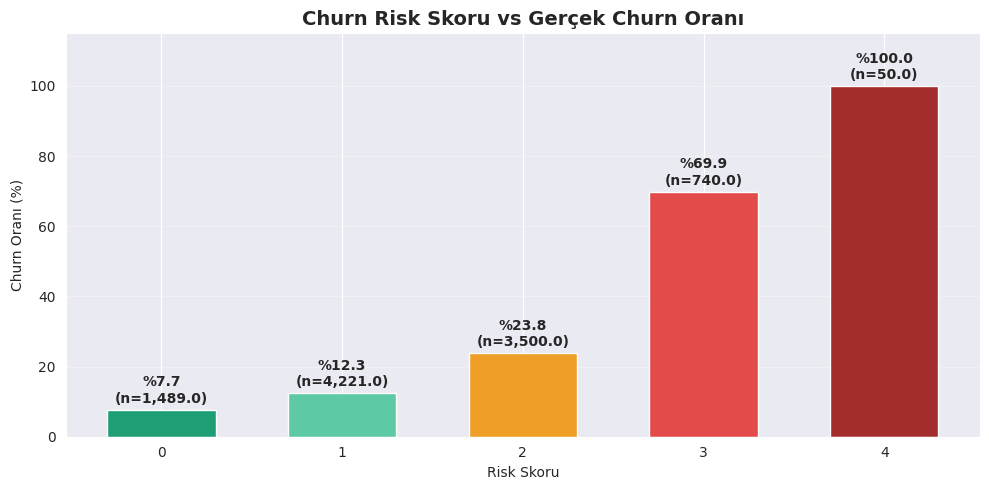

In [73]:
# Risk skoru görselleştirmesi
fig, ax = plt.subplots(figsize=(10, 5))
risk_data = df.groupby('churn_risk_score')['churn'].agg(['mean', 'count'])
risk_data.columns = ['churn_rate', 'total']
risk_data['churn_rate'] = risk_data['churn_rate'] * 100

colors_risk = ['#1D9E75', '#5DCAA5', '#EF9F27', '#E24B4A', '#A32D2D']
bars = ax.bar(risk_data.index.astype(str), risk_data['churn_rate'],
              color=colors_risk[:len(risk_data)], edgecolor='white', width=0.6)

for bar, (idx, row) in zip(bars, risk_data.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'%{row["churn_rate"]:.1f}\n(n={row["total"]:,})',
            ha='center', fontweight='bold', fontsize=10)

ax.set_title('Churn Risk Skoru vs Gerçek Churn Oranı', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Oranı (%)')
ax.set_xlabel('Risk Skoru')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

---
## 12. Engagement Skoru Analizi

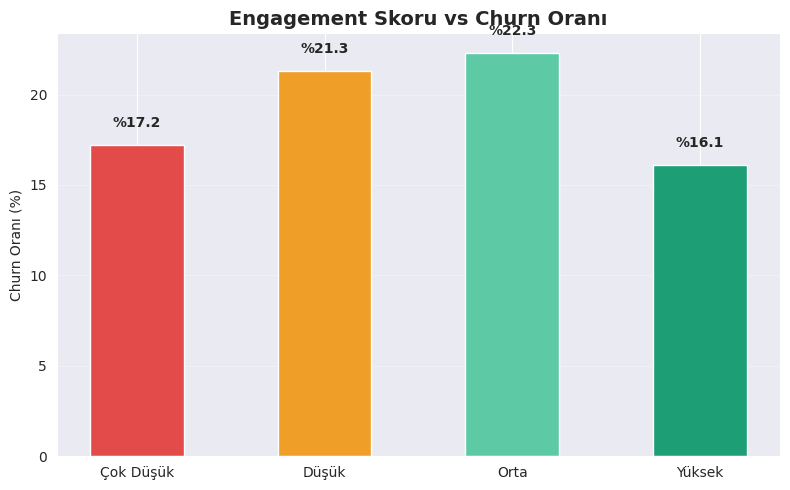

In [74]:
engagement_map = {0: 'Çok Düşük', 1: 'Düşük', 2: 'Orta', 3: 'Yüksek'}
eng_data = df.groupby('engagement_score')['churn'].agg(['mean', 'count'])
eng_data.columns = ['churn_rate', 'total']
eng_data['churn_rate'] = eng_data['churn_rate'] * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([engagement_map[i] for i in eng_data.index], eng_data['churn_rate'],
              color=['#E24B4A', '#EF9F27', '#5DCAA5', '#1D9E75'], edgecolor='white', width=0.5)

for bar, (idx, row) in zip(bars, eng_data.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'%{row["churn_rate"]:.1f}', ha='center', fontweight='bold')

ax.set_title('Engagement Skoru vs Churn Oranı', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Oranı (%)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 13. Temizlenmiş Veriyi Kaydet (BigQuery'ye Yükleme İçin)

In [75]:
# Analiz dışı sütunları çıkar
columns_to_drop = ['customer_id']
df_export = df.drop(columns=columns_to_drop, errors='ignore')

# CSV olarak kaydet
df_export.to_csv('bank_churn_features.csv', index=False)
print(f"Kaydedildi: bank_churn_features.csv")
print(f"Boyut: {df_export.shape[0]:,} satır × {df_export.shape[1]} sütun")

Kaydedildi: bank_churn_features.csv
Boyut: 10,000 satır × 24 sütun


---
## 14. Özet Bulgular

### Ana İnsightlar:

1. **Churn oranı %20.4** — her 5 müşteriden 1'i bankayı terk ediyor
2. **Yaş en güçlü sinyal** — 46-55 yaş grubunda churn %50.6, korelasyon +0.285
3. **Almanya sorunu** — Churn oranı %32.4, diğer ülkelerin 2 katı
4. **Ürün paradoksu** — 3-4 ürün kullananlarda churn %83-100
5. **Pasif üyelik riski** — Pasif üyelerde churn %26.9, aktif üyelerde %14.3
6. **Risk skoru başarısı** — Oluşturduğumuz bileşik risk skoru, skor 4'te %100 churn yakalıyor

### Önerilen Aksiyonlar:

- Almanya'daki müşteri memnuniyetini araştır
- 45+ yaş grubuna özel sadakat programı başlat
- 3+ ürün kullanan müşterilere proaktif destek sun
- Pasif üyeleri aktifleştirme kampanyası yürütülebilir
- Risk skoru 3+ olan müşterilere erken müdahale et

---

## 15. Makine Öğrenmesi Modeli

### 15.1 Veri Hazırlığı (One-Hot Encoding ve Veri Bölme)

In [76]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Re-load the original dataset for robustness. User must ensure this file is uploaded to the Colab environment.
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

# --- Re-apply feature engineering steps from previous cells for robustness ---

# age_group from cell 11743be0
df['age_group'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,100],
                         labels=['18-25','26-35','36-45','46-55','56-65','65+'])

# Feature engineering from cell be3d5f4d
df['is_zero_balance'] = (df['balance'] == 0).astype(int)
df['balance_salary_ratio'] = (df['balance'] / df['estimated_salary'].replace(0, np.nan)).round(4).fillna(0)
balance_median = df.loc[df['balance'] > 0, 'balance'].median()
df['is_high_balance'] = (df['balance'] > balance_median).astype(int)
df['balance_segment'] = pd.cut(df['balance'],
    bins=[-1, 0, 50000, 100000, 150000, 300000],
    labels=['Sıfır', 'Düşük', 'Orta', 'Yüksek', 'Çok Yüksek'])
df['credit_score_cat'] = pd.cut(df['credit_score'],
    bins=[0, 500, 600, 700, 800, 900],
    labels=['Çok Düşük', 'Düşük', 'Orta', 'İyi', 'Mükemmel'])
df['tenure_age_ratio'] = (df['tenure'] / df['age']).round(4)
df['products_per_tenure'] = (df['products_number'] / (df['tenure'] + 1)).round(4)
df['is_multi_product'] = (df['products_number'] >= 2).astype(int)
df['is_high_risk_products'] = (df['products_number'] >= 3).astype(int)
df['engagement_score'] = (df['active_member'] + df['credit_card'] + (df['balance'] > 0).astype(int))
df['churn_risk_score'] = (
    (df['age'] >= 45).astype(int) +
    (df['active_member'] == 0).astype(int) +
    (df['products_number'] >= 3).astype(int) +
    (df['country'] == 'Germany').astype(int) +
    (df['balance'] == 0).astype(int)
)

# churn_risk_segment from cell 650370c1
risk_map = {0: 'Çok Düşük', 1: 'Düşük', 2: 'Orta', 3: 'Yüksek', 4: 'Çok Yüksek', 5: 'Kritik'}
df['churn_risk_segment'] = df['churn_risk_score'].map(risk_map)

# --- End re-apply feature engineering steps ---

# customer_id ve daha önce oluşturulan segment sütunları gibi analize dahil edilmeyecek sütunları çıkaralım
# churn_risk_score zaten bir risk değerlendirmesi olduğundan, modelin kendisini öğrenmesini sağlamak için çıkaralım
columns_to_drop_for_ml = ['customer_id', 'churn_risk_score', 'churn_risk_segment', 'balance_segment', 'credit_score_cat', 'age_group']
df_ml = df.drop(columns=columns_to_drop_for_ml, errors='ignore').copy()

# Kategorik değişkenleri one-hot encode edelim
df_ml = pd.get_dummies(df_ml, columns=['country', 'gender'], drop_first=True)

# Hedef değişken ve özellikler
X = df_ml.drop('churn', axis=1)
y = df_ml['churn']

# Eğitim ve test setlerine ayıralım
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Eğitim seti boyutu: {X_train.shape}")
print(f"Test seti boyutu: {X_test.shape}")
print("Veri hazırlığı tamamlandı.")

Eğitim seti boyutu: (8000, 19)
Test seti boyutu: (2000, 19)
Veri hazırlığı tamamlandı.


### 15.2 Modeli Eğitme (Random Forest Classifier)

In [77]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest sınıflandırıcı modelini tanımlayalım
# Sınıf dengesizliğini ele almak için class_weight='balanced' kullanalım
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Modeli eğitelim
model.fit(X_train, y_train)

print("Random Forest modeli başarıyla eğitildi ve tahmin yapmaya hazır!")

Random Forest modeli başarıyla eğitildi ve tahmin yapmaya hazır!


### 15.3 Model Değerlendirmesi

Accuracy: 0.8620
Precision: 0.7937
Recall: 0.4349
F1 Score: 0.5619


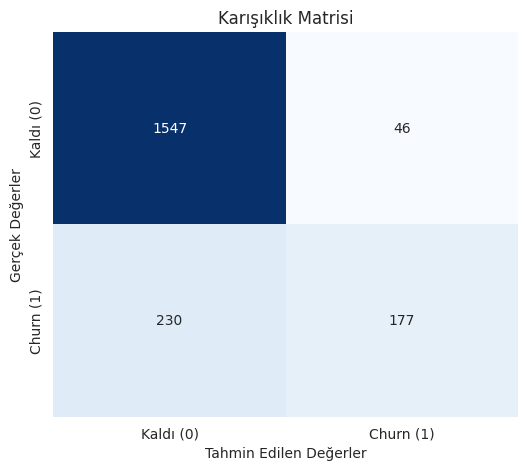

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Test seti üzerinde tahmin yapalım
y_pred = model.predict(X_test)

# Model performansını değerlendirelim
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Karışıklık Matrisini görselleştirelim
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Kaldı (0)', 'Churn (1)'], yticklabels=['Kaldı (0)', 'Churn (1)'])
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Gerçek Değerler')
plt.title('Karışıklık Matrisi')
plt.show()

### 15.4 Özellik Önem Dereceleri (Feature Importances)

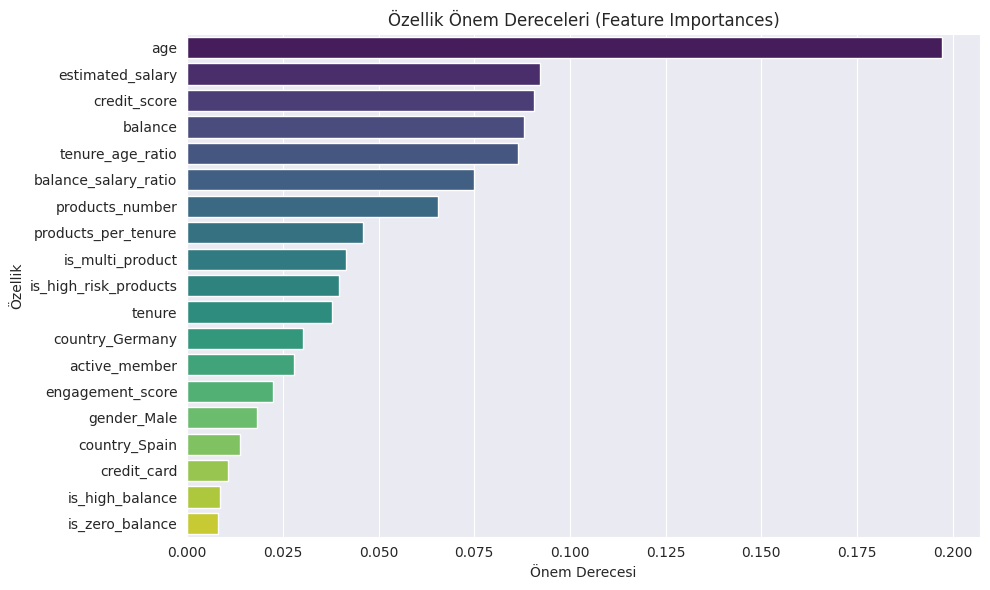

,Feature,Importance
1,age,0.197285
7,estimated_salary,0.092205
0,credit_score,0.090598
3,balance,0.088137
11,tenure_age_ratio,0.086444
9,balance_salary_ratio,0.074836
4,products_number,0.065516
12,products_per_tenure,0.046011
13,is_multi_product,0.041583
14,is_high_risk_products,0.039586


In [79]:
# Özellik önem derecelerini alalım
feature_importances = model.feature_importances_
features = X.columns

# Önem derecelerini bir DataFrame'e dönüştürelim ve sıralayalım
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Özellik önem derecelerini görselleştirelim
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Özellik Önem Dereceleri (Feature Importances)')
plt.xlabel('Önem Derecesi')
plt.ylabel('Özellik')
plt.tight_layout()
plt.show()

display(importance_df)

---
## 16. Modeli Kaydetme ve BigQuery'ye Aktarım

In [80]:
import joblib
import os

# 1. Modeli yerel diske kaydetme (Gelecekteki kullanımlar veya API dağıtımı için)
model_filename = 'random_forest_churn_model.pkl'
joblib.dump(model, model_filename)

print(f"Model başarıyla kaydedildi: {model_filename}")
print(f"Dosya boyutu: {os.path.getsize(model_filename) / (1024*1024):.2f} MB")

Model başarıyla kaydedildi: random_forest_churn_model.pkl
Dosya boyutu: 18.09 MB


### 16.1 Tahminleri Oluşturma ve BigQuery'ye Yazma
Scikit-learn modelini doğrudan BigQuery ML içine import etmek için modeli ONNX formatına çevirmek gereklidir. Bunun yerine en sık kullanılan yöntem, Colab üzerinde tüm müşteriler için **Churn Olasılıklarını (Risk)** hesaplayıp, müşteri ID'leri ile birlikte sonucu BigQuery tablosu olarak yazmaktır.

In [81]:
# Tüm veri seti için tahminleri ve churn olasılıklarını hesaplayalım
df_final = df.copy()
df_final['churn_prediction'] = model.predict(X)
df_final['churn_probability'] = model.predict_proba(X)[:, 1] # 1 (Churn) olma olasılığı

# Sadece BigQuery'ye aktarılacak önemli sütunları seçelim
bq_export_df = df_final[['customer_id', 'churn', 'churn_prediction', 'churn_probability', 'churn_risk_segment']]

display(bq_export_df.head())
print(f"\nBigQuery'ye aktarılacak tablo boyutu: {bq_export_df.shape}")

,customer_id,churn,churn_prediction,churn_probability,churn_risk_segment
0,15634602,1,1,0.71,Düşük
1,15647311,0,0,0.12,Çok Düşük
2,15619304,1,1,1.00,Orta
3,15701354,0,0,0.00,Orta
4,15737888,0,0,0.06,Çok Düşük



BigQuery'ye aktarılacak tablo boyutu: (10000, 5)


In [82]:
# --- BIGQUERY AKTARIM KODU ---
from google.colab import auth
import pandas_gbq

# 1. Google Cloud hesabınıza giriş yapın
auth.authenticate_user()

# 2. Project ID ve Table ID ayarları
PROJECT_ID = 'bank-customer-churn-dataset'
TABLE_ID = 'banka_veriseti.musteri_churn_tahminleri' # DatasetAdı.TabloAdı formatında

print(f"\nVeriler BigQuery'ye ({PROJECT_ID}.{TABLE_ID}) aktarılıyor...")
try:
    # 3. DataFrame'i BigQuery'ye yazma
    pandas_gbq.to_gbq(
        bq_export_df,
        destination_table=TABLE_ID,
        project_id=PROJECT_ID,
        if_exists='replace' # Tablo varsa üzerine yazar ('append' ile sonuna ekleyebilirsiniz)
    )
    print("🎉 Tahminler başarıyla BigQuery'ye aktarıldı!")
except Exception as e:
    print(f"\n❌ Aktarım sırasında hata oluştu: {e}")
    print("\nNOT: Eğer 'Dataset not found' veya 'API not enabled' hatası alıyorsanız:")
    print(f"1. Google Cloud Console'da '{PROJECT_ID}' projesine gidin.")
    print("2. BigQuery API'nin etkinleştirildiğinden emin olun.")
    print("3. BigQuery'de 'banka_veriseti' adında bir Dataset oluşturduğunuzdan emin olun.")


Veriler BigQuery'ye (bank-customer-churn-dataset.banka_veriseti.musteri_churn_tahminleri) aktarılıyor...


100%|██████████| 1/1 [00:00<00:00, 9776.93it/s]

🎉 Tahminler başarıyla BigQuery'ye aktarıldı!
